In [61]:
#######################################Health Insurance Claim Severity & Risk Analysis
#Analysed insurance claim severity drivers using demographic and health-related variables, identifying key factors influencing claim cost distribution.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
#importing datatset
df = pd.read_csv("../Data/insurance_data.csv")
#df.to_excel("../Data/Cleaned.xlsx", index=False)

#print(df.isnull().sum())
df = df.dropna()
#print(df.info())
print(df.isnull().sum())

index            0
PatientID        0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64


<Axes: >

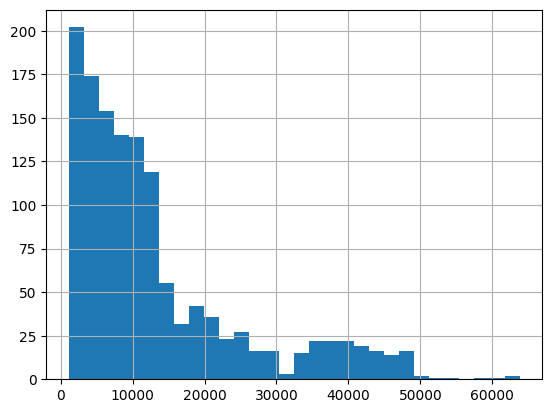

In [63]:
df["claim"].describe()
df["claim"].hist(bins=30)


In [64]:
'''Claim amounts exhibit a strongly right-skewed distribution, with the majority of claims concentrated at lower 
values and a long tail of high-cost claims, indicating the presence of significant severity risk in extreme cases
'''

'Claim amounts exhibit a strongly right-skewed distribution, with the majority of claims concentrated at lower \nvalues and a long tail of high-cost claims, indicating the presence of significant severity risk in extreme cases\n'

In [65]:
#Diabetic versus Claims
df.groupby("diabetic")["claim"].mean()

#--> Diabetic and non-diabetic groups show very similar average claim amounts, 
# indicating limited standalone predictive power of diabetes status for claim severity within this dataset

diabetic
No     13406.602173
Yes    13236.483093
Name: claim, dtype: float64

In [66]:
#Smoker versus Claims
df.groupby("smoker")["claim"].mean()
#--> There is a clear difference in average claim amounts between smokers and non-smokers. 
# Smokers have significantly higher claims, at roughly four times the value of non-smokers. Based on this observation alone, smoking appears to be a strong risk indicator for claim severity in this dataset.



smoker
No      8475.864537
Yes    32050.231971
Name: claim, dtype: float64

In [67]:
#BMI versus Claims
df.groupby(pd.cut(df["bmi"], bins=5))["claim"].mean()
#There is a clear upward trend in claim amounts as BMI increases. 
# Higher BMI groups are associated with higher average claims, suggesting BMI is a strong risk indicator for 
# insurance cost in this dataset. While the relationship is not strictly linear and may vary across bins, 
# the overall pattern shows increasing severity with higher BMI.

C:\Users\wieda\AppData\Local\Temp\ipykernel_15292\1207010479.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["bmi"], bins=5))["claim"].mean()


bmi
(15.963, 23.42]     9366.469812
(23.42, 30.84]     11644.480766
(30.84, 38.26]     15944.078117
(38.26, 45.68]     15149.054961
(45.68, 53.1]      17289.422353
Name: claim, dtype: float64

In [68]:
#BP vs Claims
df.groupby(pd.cut(df["bloodpressure"], bins=5))["claim"].mean()
#There is a strong upward trend between blood pressure and claim amounts. 
# Higher blood pressure groups are associated with significantly higher average claims, 
# suggesting it is a strong risk indicator for claim severity in this dataset.

C:\Users\wieda\AppData\Local\Temp\ipykernel_15292\4058923312.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["bloodpressure"], bins=5))["claim"].mean()


bloodpressure
(79.94, 92.0]      9705.881224
(92.0, 104.0]     12191.338915
(104.0, 116.0]    23558.876129
(116.0, 128.0]    39033.066486
(128.0, 140.0]    36965.919687
Name: claim, dtype: float64

In [69]:
######################################univariate comparisons

In [70]:
#BP+ SMOKER 
df.groupby(["smoker", pd.cut(df["bloodpressure"], 5)])["claim"].mean()
'''Smoking appears to have the strongest association with higher claim amounts across all blood pressure groups. Within both smokers and non-smokers, higher blood pressure is also associated with higher average claim amounts, suggesting that blood pressure remains an important factor even after separating by smoking status.'''

C:\Users\wieda\AppData\Local\Temp\ipykernel_15292\2983578791.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["smoker", pd.cut(df["bloodpressure"], 5)])["claim"].mean()


'Smoking appears to have the strongest association with higher claim amounts across all blood pressure groups. Within both smokers and non-smokers, higher blood pressure is also associated with higher average claim amounts, suggesting that blood pressure remains an important factor even after separating by smoking status.'

In [71]:
df.groupby(["smoker", pd.cut(df["bmi"], 5)])["claim"].mean()
''''BMI appears to have a much stronger relationship with claim severity among smokers than among non-smokers.'''

C:\Users\wieda\AppData\Local\Temp\ipykernel_15292\1259684030.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["smoker", pd.cut(df["bmi"], 5)])["claim"].mean()


"'BMI appears to have a much stronger relationship with claim severity among smokers than among non-smokers."

In [72]:
'''''''''Preparing Data'''

'Preparing Data'

In [73]:
df.dtypes

for col in ["gender", "diabetic", "smoker", "region"]:
    print(f"\n{col}")
    print(df[col].unique())


gender
['male' 'female']

diabetic
['Yes' 'No']

smoker
['No' 'Yes']

region
['southeast' 'northwest' 'southwest' 'northeast']


In [74]:
'''''''Building Regression Model'''


'Building Regression Model'

In [75]:
# ML cannot read text, change intp 0 and 1
df["smoker"] = df["smoker"].map({"Yes": 1, "No": 0})
df["diabetic"] = df["diabetic"].map({"Yes": 1, "No": 0})
df["gender"] = df["gender"].map({"male": 1, "female": 0})

df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [76]:
#defining x and y
y = df["claim"]
X = df.drop("claim", axis=1)

In [77]:
from sklearn.model_selection import train_test_split
X = df.drop(["claim", "index", "PatientID"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [78]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 15.02, -42.59, 327.39,...,-1557.95,-2442.33,-2193.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','gender','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.235e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [79]:
y_pred = model.predict(X_test)

In [80]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 4910.906546802689
R²: 0.7303130998448941


In [81]:
''''Most of the variation in insurance claims can be explained using a small set of health and lifestyle variables'''
'''smoker = huge effect
BMI = strong effect
blood pressure = strong effect
diabetes = weak effect'''

'smoker = huge effect\nBMI = strong effect\nblood pressure = strong effect\ndiabetes = weak effect'

In [82]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients

,Feature,Coefficient
6,smoker,20545.568590
5,children,805.094186
2,bmi,327.392006
3,bloodpressure,231.882481
0,age,15.022018
1,gender,-42.586644
4,diabetic,-453.521472
7,region_northwest,-1557.947050
9,region_southwest,-2193.331824
8,region_southeast,-2442.329873


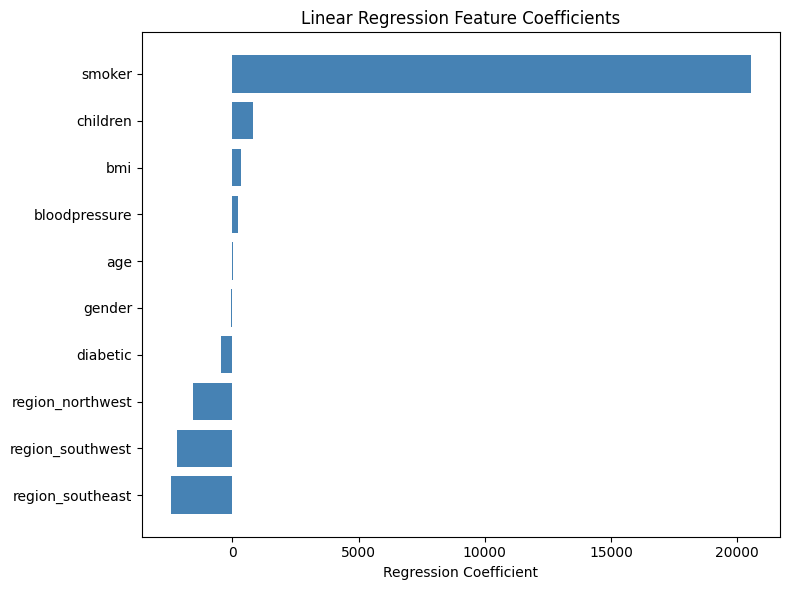

In [89]:
import matplotlib.pyplot as plt

coefficients_sorted = coefficients.sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(coefficients_sorted["Feature"],
         coefficients_sorted["Coefficient"],
         color="steelblue")

plt.xlabel("Regression Coefficient")
plt.title("Linear Regression Feature Coefficients")
plt.tight_layout()
plt.show()


In [90]:
'''Strongest driver
Smoking (dominant by far)
Secondary drivers
BMI
Blood pressure
Children (now more visible)
Weak drivers
Age
Gender
Diabetes
Contextual factors
Region (small adjustments only)'''

'Strongest driver\nSmoking (dominant by far)\nSecondary drivers\nBMI\nBlood pressure\nChildren (now more visible)\nWeak drivers\nAge\nGender\nDiabetes\nContextual factors\nRegion (small adjustments only)'

In [91]:
#Exporting into an excel doc
df.to_excel("../Data/Cleaned.xlsx", index=False)